In [1]:
from ipynb.fs.full. magic_flow_model import *
from ipynb.fs.full. data_loader import *
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve, auc, 
    precision_recall_curve, average_precision_score, accuracy_score
)
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim 
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, CosineAnnealingLR
from tqdm import tqdm

## Directory Setup

In [2]:
# Define the base path
base_path = os.getcwd()
print("Base path:", base_path)

# Define some additions
data_path = os.path.join(base_path, "datasets/scanner_data7")
model_folder = os.path.join(base_path, "saved_ckpt")

# Create directories if they do not exist
os.makedirs(model_folder, exist_ok=True)

# Print paths
print("Data Path:", data_path)
print("Saved Model Path:", model_folder)

# Check existence
print("Data path exists:", os.path.exists(data_path))
print("Saved Model Path exists:", os.path.exists(model_folder))

Base path: /home/almalinux/data/jupyter_notebooks/cNF_folder/MAGIC-Flow/classification
Data Path: /home/almalinux/data/jupyter_notebooks/cNF_folder/MAGIC-Flow/classification/datasets/scanner_data7
Saved Model Path: /home/almalinux/data/jupyter_notebooks/cNF_folder/MAGIC-Flow/classification/saved_ckpt
Data path exists: True
Saved Model Path exists: True


## Dataset Configuration

In [3]:
NUM_CLASSES = 7
pad_size = (184, 184) # pad to a dimension divisible by 4

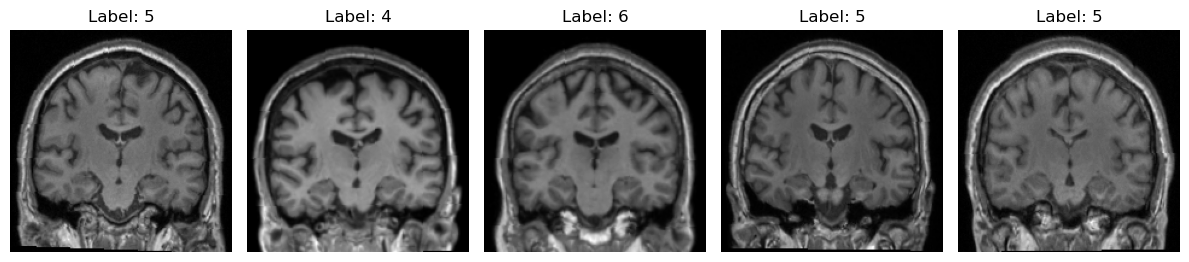

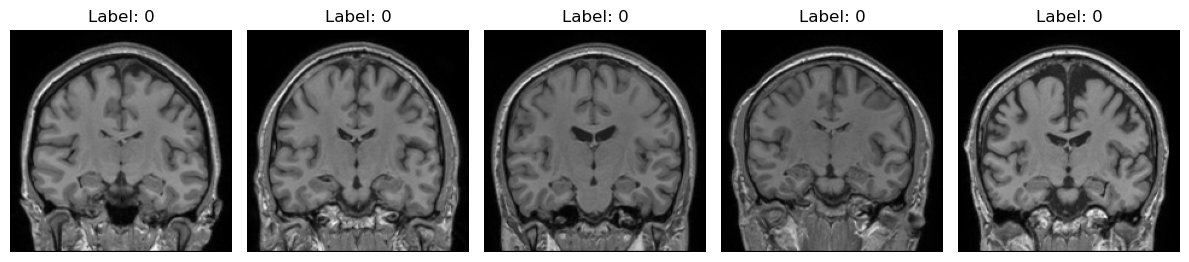

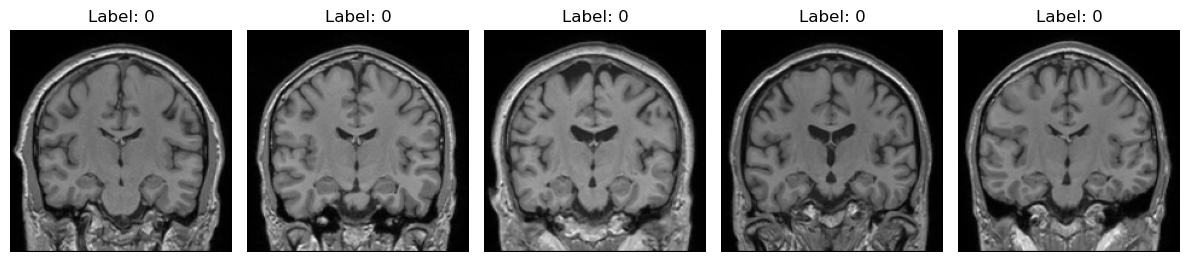

In [4]:
# ---------------------
# Dataset Paths and Config
# ---------------------
train_dir = os.path.join(data_path, "train")
val_dir = os.path.join(data_path, "val")
test_dir = os.path.join(data_path, "test")
batch_size = 16


train_dataset = GrayscaleImageDataset(
    root_dir=train_dir,
    num_classes=NUM_CLASSES,
    add_noise=True,
    noise_std=0.01,
    pad_to=pad_size,
    split="train"
)

valid_dataset = GrayscaleImageDataset(
    root_dir=val_dir,
    num_classes=NUM_CLASSES,
    pad_to=pad_size,
    split="val"
)

test_dataset = GrayscaleImageDataset(
    root_dir=test_dir,
    num_classes=NUM_CLASSES,
    pad_to=pad_size,
    split="test"
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ---------------------
# Visualize: Images
# ---------------------
def show_images(data_loader, num_images=5):
    data_iter = iter(data_loader)
    images, labels = next(data_iter)

    plt.figure(figsize=(12, 3))
    for i in range(num_images):
        img = images[i].squeeze().numpy()
        img = (img + 1) / 2  # Unnormalize from [-1, 1] to [0, 1] for display
        img = np.rot90(img, k=1)
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"Label: {torch.argmax(labels[i]).item()}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_images(train_loader)
show_images(valid_loader)
show_images(test_loader)

## Model SetUp

In [5]:
n_epochs = 400

# Path to your preprocessed mask image (184x184 PNG)
mask_path = os.path.join(os.path.dirname(base_path), 'custom_png/coronal_slice_110_rotated.png') 

# Load image as float tensor
mask_img = Image.open(mask_path).convert('L')
mask_np = np.array(mask_img)  # shape (H, W)
mask_tensor = torch.from_numpy(mask_np).float() / 255.0  # values 0.0 or 1.0

filters_per_layer = [
    (16, 16, 32), (16, 16, 32), (16, 32, 32),  (16, 32, 32), (16, 32, 32),
    # 
    (16, 32, 32), (16, 32, 64), (16, 32, 64),
    # 
    (16, 32, 64), (16, 32, 64), (16, 64, 64),
    # 
    (32, 64, 64), (32, 64, 64), (32, 64, 64),
    # 
    (32, 64, 128), (32, 64, 128), (32, 64, 128),
    # 
    (64, 64, 128), (64, 64, 128), (64, 64, 128),
    # 
    (64, 128, 128), (64, 128, 128), (128, 256, 256), (128, 256, 256)
]

mask_types = (
    ['custom'] + ['checkerboard'] * 4 +                     
    (['channel'] * 3 + ['checkerboard'] * 3) * 2 +  
    ['channel'] * 3 +                          
    ['checkerboard'] * 4                      
)


real_nvp = CondMSRealNVP(
        num_coupling_layers=24,
        num_classes=NUM_CLASSES,
        input_shape=(1, 184, 184),
        squeeze_layers=[5, 11, 17],
        split_layers=[7, 13, 19],
        layer_filters=filters_per_layer,
        mask_types=mask_types,
        verbose = False
    )

# Assign to model
real_nvp.custom_mask_tensor = mask_tensor  # (H, W)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
real_nvp = real_nvp.to(device)

initial_lr = 1e-3
optimizer = optim.Adam(real_nvp.parameters(), lr=initial_lr)

warmup_epochs = 8  # you can adjust (5–10 is typical for flows)

# 1. Linear warmup from 1% of initial_lr up to full initial_lr
warmup = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=1e-2, end_factor=1.0, total_iters=warmup_epochs
)

# 2. Cosine annealing for the remaining epochs
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=n_epochs - warmup_epochs, eta_min=1e-5
)

# 3. Chain them together
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[warmup, cosine], milestones=[warmup_epochs]
)

In [6]:
def compute_class_priors(dataset_root, class_names, device):
    class_counts = []
    total = 0

    for cls in class_names:
        cls_path = os.path.join(dataset_root, cls)
        count = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
        class_counts.append(count)
        total += count

    class_priors = torch.tensor([c / total for c in class_counts], device=device)
    return class_priors

dataset_root = os.path.join(data_path, "train")
class_names = ['Guys', 'HH', 'IOP', 'Prisma', 'PrismaFit', 'SALD', 'Triotim']

class_priors = compute_class_priors(dataset_root, class_names, device)
print(class_priors)

tensor([0.2380, 0.1370, 0.0557, 0.0512, 0.1235, 0.3645, 0.0301],
       device='cuda:0')


## Training Loop

In [ ]:
# --------------------
# Configuration
# --------------------
n_epochs = 300
resume = False  # Resume training from checkpoint
checkpoint_interval_epochs = 200
checkpoint_path = os.path.join(model_folder, "best_val_loss.pth")

# Directories
#os.makedirs(img_folder, exist_ok=True)
os.makedirs(model_folder, exist_ok=True)

# Resume setup
start_epoch = 0
global_step = 0
history = {"loss": [], "val_loss": [], "val_acc": []}

if resume and os.path.exists(checkpoint_path):
    print(f"Resuming from checkpoint: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    real_nvp.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    history = checkpoint.get("history", history)
    start_epoch = checkpoint.get("epoch", 0)
    global_step = checkpoint.get("global_step", 0)
    print(f"Resumed from epoch {start_epoch + 1}, global step {global_step}")

# --------------------
# Setup for best checkpoints
# --------------------
best_val_loss = float("inf")
best_val_acc = 0.0

# --------------------
# Training loop
# --------------------
for epoch in range(start_epoch, n_epochs):
    real_nvp.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}"):
        images, labels = images.to(device), labels.to(device)
        loss, log_likelihood_z, log_det_inv = real_nvp.train_step(images, labels, optimizer)
        running_loss += loss
        global_step += 1

    avg_loss = running_loss / len(train_loader)
    history["loss"].append(avg_loss)

    # --------------------
    # Validation: loss
    # --------------------
    real_nvp.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            log_likelihood_z, log_det_inv = real_nvp.compute_loss(images, labels)
            val_loss = -(log_likelihood_z + log_det_inv)
            running_val_loss += val_loss.item()

    avg_val_loss = running_val_loss / len(valid_loader)
    history["val_loss"].append(avg_val_loss)

    # --------------------
    # Validation: disease accuracy every 3 epochs
    # --------------------
    val_acc = None
    if (epoch + 1) % 1 == 0:
        all_preds, all_targets = [], []

        with torch.no_grad():
            for images, one_hot in valid_loader:
                images, one_hot = images.to(device), one_hot.to(device)
                B = images.size(0)

                true_label = one_hot

                log_likelihoods = []
                for d in range(NUM_CLASSES):
                    y = torch.zeros((B, NUM_CLASSES), device=device)
                    y[:, d] = 1
                    ll = real_nvp.predict(images, y)
                    log_likelihoods.append(ll.unsqueeze(-1))

                log_likelihoods = torch.cat(log_likelihoods, dim=1)
                log_posteriors = log_likelihoods + torch.log(class_priors).view(1, -1)

                preds = torch.argmax(log_posteriors, dim=1)
                targets = torch.argmax(true_label, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())

        val_acc = accuracy_score(all_targets, all_preds)
        history["val_acc"].append(val_acc)
        print(f"Epoch [{epoch+1}/{n_epochs}] "
              f"Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")
    else:
        history["val_acc"].append(None)
        print(f"Epoch [{epoch+1}/{n_epochs}] "
              f"Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    scheduler.step()

    # --------------------
    # Save best checkpoints
    # --------------------
    ckpt_dict = {
        "epoch": epoch + 1,
        "global_step": global_step,
        "model_state_dict": real_nvp.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "history": history
    }

    # Save best val loss
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(ckpt_dict, os.path.join(model_folder, "best_val_loss.pth"))
        print(f"✅ Saved new best model (val loss {best_val_loss:.4f})")

    # Save best val acc
    if val_acc is not None and val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(ckpt_dict, os.path.join(model_folder, "best_val_acc.pth"))
        print(f"✅ Saved new best model (val acc {best_val_acc:.4f})")

    # --------------------
    # Save periodic checkpoints
    # --------------------
    if checkpoint_interval_epochs > 0 and (epoch + 1) % checkpoint_interval_epochs == 0:
        extra_ckpt_path = os.path.join(model_folder, f"checkpoint_epoch{epoch+1}.pth")
        torch.save(ckpt_dict, extra_ckpt_path)
        print(f"💾 Saved periodic checkpoint at: {extra_ckpt_path}")